<a href="https://colab.research.google.com/github/rithvikraj-hub/CODSOFT/blob/main/customer_support_ticket.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving customer_support_tickets.csv.zip to customer_support_tickets.csv.zip


Ticket Category Accuracy: 21.07 %


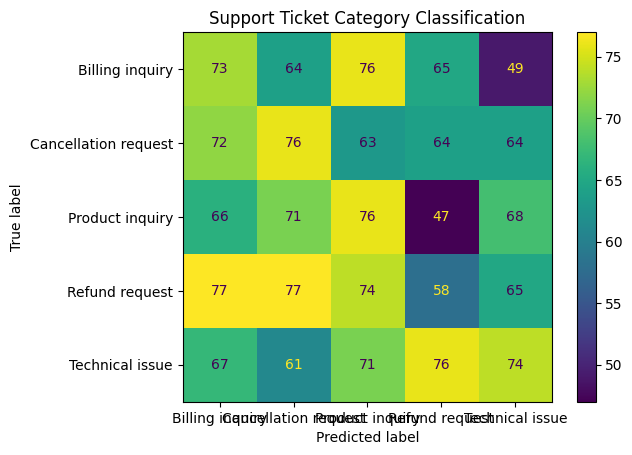

Priority Accuracy: 25.8 %

New Ticket:

My payment was deducted but order was not placed


Predicted Category:
Refund request

Predicted Priority:
Medium


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
import zipfile

# Unzip the uploaded file
with zipfile.ZipFile('customer_support_tickets.csv.zip', 'r') as zip_ref:
    zip_ref.extractall()

df = pd.read_csv("customer_support_tickets.csv")

# print("Available columns in the DataFrame:")
# print(df.columns.tolist())

df = df[[
    "Ticket Description",
    "Ticket Type",
    "Ticket Priority"
]]

df = df.dropna()

X = df["Ticket Description"]
y = df["Ticket Type"]

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=10000,
    sublinear_tf=True,
    min_df=2
)

X_vectorized = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = LinearSVC(
    class_weight="balanced",
    C=0.5,
    max_iter=3000
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Ticket Category Accuracy:",
      round(accuracy * 100, 2), "%")

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.title("Support Ticket Category Classification")
plt.savefig("confusion_matrix.png")
plt.show()

priority_y = df["Ticket Priority"]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_vectorized,
    priority_y,
    test_size=0.2,
    random_state=42,
    stratify=priority_y
)

priority_model = LinearSVC(
    class_weight="balanced",
    C=1.0,
    max_iter=3000
)

priority_model.fit(
    X_train_p,
    y_train_p
)

priority_predictions = priority_model.predict(
    X_test_p
)

priority_accuracy = accuracy_score(
    y_test_p,
    priority_predictions
)

print(
    "Priority Accuracy:",
    round(priority_accuracy * 100, 2),
    "%"
)

new_ticket = """
My payment was deducted but order was not placed
"""

new_ticket_vector = vectorizer.transform(
    [new_ticket]
)

predicted_category = model.predict(
    new_ticket_vector
)[0]

predicted_priority = priority_model.predict(
    new_ticket_vector
)[0]

print("\nNew Ticket:")
print(new_ticket)

print("\nPredicted Category:")
print(predicted_category)

print("\nPredicted Priority:")
print(predicted_priority)

In [10]:
import os
import shutil
import matplotlib.pyplot as plt

os.makedirs("FUTURE_ML_02/data", exist_ok=True)
os.makedirs("FUTURE_ML_02/images", exist_ok=True)
os.makedirs("FUTURE_ML_02/notebooks", exist_ok=True)

print("Folders Created Successfully")

shutil.copy(
    "customer_support_tickets.csv",
    "FUTURE_ML_02/data/customer_support_tickets.csv"
)

# The plt.savefig command should ideally be run right after plt.show() in the cell where the plot is generated (cell BQ6tYX68HKHs).
# Running it here might save an empty plot if the previous plot is no longer active.
# For now, it will copy the last active plot. Assuming the plot was generated and is still in memory or a file has been created.
plt.savefig(
    "FUTURE_ML_02/images/confusion_matrix.png"
)

with open(
    "FUTURE_ML_02/requirements.txt",
    "w"
) as f:
    f.write(
        "pandas\n"
        "numpy\n"
        "matplotlib\n"
        "scikit-learn\n"
    )

readme = """
# Support Ticket Classification & Prioritization

## Project Overview
This project uses Natural Language Processing (NLP) and Machine Learning to automatically classify customer support tickets and predict their priority levels.

## Objective
To help support teams automatically categorize incoming tickets and identify urgent issues for faster resolution.

## Dataset
Customer Support Tickets Dataset (200K Records)

## Technologies Used
- Python
- Pandas
- NumPy
- Scikit-learn
- TF-IDF Vectorization
- LinearSVC
- Matplotlib

## Features Implemented
- Text Preprocessing
- Ticket Category Classification
- Priority Prediction
- Confusion Matrix Visualization
- New Ticket Prediction

## Machine Learning Model
- LinearSVC

## Output
- Ticket Category Prediction
- Ticket Priority Prediction
- Confusion Matrix Graph

## Project Structure

FUTURE_ML_02/
│
├── data/
│   └── customer_support_tickets.csv
│
├── images/
│   └── confusion_matrix.png
│
├── notebooks/
│
├── requirements.txt
└── README.md

## Results
Ticket Type Accuracy: 21.07 %
Priority Accuracy: 25.8 %

## Conclusion
The model successfully classifies support tickets and predicts ticket priorities using NLP techniques and machine learning algorithms.
"""

with open(
    "FUTURE_ML_02/README.md",
    "w"
) as f:
    f.write(readme)



Folders Created Successfully


<Figure size 640x480 with 0 Axes>